## Introducción a Pandas

La librería Pandas, de manera genérica, contiene las siguientes estructuras de datos:
* **Series**: Array de una dimensión
* **DataFrame**: Se corresponde con una tabla de 2 dimensiones
* **Panel**: Similar a un diccionario de DataFrames

In [1]:
## Trabajando con series
import pandas as pd

In [2]:
#Creando serie de numeros
serie1 = pd.Series([2, 4, 6, 8, 10])
print(serie1)

0     2
1     4
2     6
3     8
4    10
dtype: int64


In [3]:
#Creando serie a partir de un diccionario
edades = {"Pedro": 20, "Maria": 24, "Juan": 21, "Luis": 28}
serie2 = pd.Series(edades)
print(serie2)

Pedro    20
Maria    24
Juan     21
Luis     28
dtype: int64


In [4]:
#Creando una serie con datos seleccionados
serie3 = pd.Series(edades, index = ["Pedro", "Luis"])
print(serie3)

Pedro    20
Luis     28
dtype: int64


In [5]:
#Accediendo a un elemento de la lista
print(serie3["Pedro"])

20


In [7]:
#Accediendo a un elemento de la lista
print(serie1[3])

8


## Resepresentación gráfica de una serie

In [8]:
# Creación de un objeto Series con lecturas de Temperaturas
temperaturas = [4.4, 5.1, 6.1, 6.2, 6.1, 6.1, 5.7, 5.2, 4.7, 4.1, 3.9]
s = pd.Series(temperaturas, name="Temperaturas")
print(s)

0     4.4
1     5.1
2     6.1
3     6.2
4     6.1
5     6.1
6     5.7
7     5.2
8     4.7
9     4.1
10    3.9
Name: Temperaturas, dtype: float64


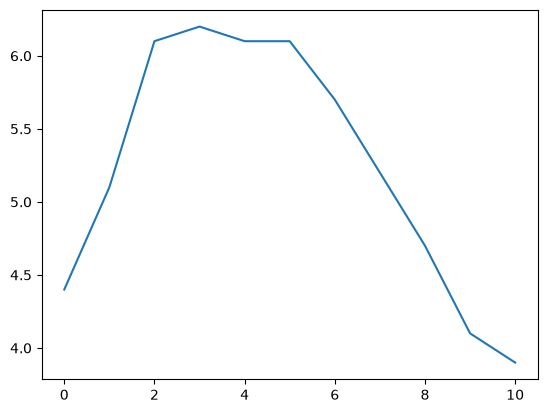

In [9]:
# Importando libreria de graficos (Previamente se debe instalar la libreria: python -m pip install matplotlib)
import matplotlib.pyplot as plt

# Creando grafico
s.plot()
# Mostrando el gráfico
plt.show()

## Creando DataFrames

In [10]:
# Creación de un DataFrame inicializándolo con un diccionario de objetios Series
personas = {
    "peso": pd.Series([84, 90, 56, 64], ["Santiago","Pedro", "Ana", "Julia"]),
    "altura": pd.Series({"Santiago": 187, "Pedro": 178, "Julia": 170, "Ana": 165}),
    "hijos": pd.Series([2, 3], ["Pedro", "Julia"])
}

df = pd.DataFrame(personas)
df

,peso,altura,hijos
Ana,56,165,NaN
Julia,64,170,3.0
Pedro,90,178,2.0
Santiago,84,187,NaN


In [11]:
# Creando un dataframe con datos seleccionados
df1 = pd.DataFrame(
    personas,
    columns = ["altura", "peso"],
    index = ["Ana", "Julia", "Santiago"]
)
df1

,altura,peso
Ana,165,56
Julia,170,64
Santiago,187,84


In [12]:
# Creando un DataFrame a partir de una matriz personalizada
matriz = [
    [185, 5, 76],
    [156, 0, 65],
    [172, 2, 68]
]

df2 = pd.DataFrame(
    matriz,
    columns = ["Altura", "Hijos", "Peso"],
    index = ["Pedro", "Ana", "Juan"]
)
df2

,Altura,Hijos,Peso
Pedro,185,5,76
Ana,156,0,65
Juan,172,2,68


In [14]:
# Creando un DataFrame a partir de un diccionario simple
personas = {
    "Altura": {"Pedro": 173, "Maria": 165, "Juan": 182, "Luis": 155},
    "Peso": {"Pedro": 69, "Maria": 61, "Juan": 83, "Luis": 73},
    "Edades": {"Pedro": 35, "Maria": 27, "Juan": 38, "Luis": 24}
}

df3 = pd.DataFrame(personas)
df3

,Altura,Peso,Edades
Pedro,173,69,35
Maria,165,61,27
Juan,182,83,38
Luis,155,73,24


In [36]:
# Practica 1: Crear un data frame con los reportes de ventas de las sucursales: Arequipa, Ica y Lima y 
# categoria de productos: Tecnologia, Limpieza, Frutas, Verduras
ventas = [
    [12500, 8400, 6300, 7100],
    [9800, 7600, 5900, 6800],
    [15800, 10200, 7200, 8500]
]

df_ventas = pd.DataFrame(
    ventas,
    columns = ["Tecnologia", "Limpieza", "Frutas", "Verduras"],
    index = ["Arequipa", "Ica", "Lima"]
)
df_ventas

,Tecnologia,Limpieza,Frutas,Verduras
Arequipa,12500,8400,6300,7100
Ica,9800,7600,5900,6800
Lima,15800,10200,7200,8500


## Accediendo a los datos de un DataFrames

In [ ]:
# Seleccionar la columna Peso
df3["Peso"]

Pedro    69
Maria    61
Juan     83
Luis     73
Name: Peso, dtype: int64

In [ ]:
# Seleccionar la columna Altura
df3["Altura"]

Pedro    173
Maria    165
Juan     182
Luis     155
Name: Altura, dtype: int64

In [18]:
# Seleccionar mas de una columna (Edades, Peso)
df3[["Edades", "Peso"]]

,Edades,Peso
Pedro,35,69
Maria,27,61
Juan,38,83
Luis,24,73


In [19]:
# Seleccionar las columnas Tecnologia y Frutas
df_ventas[["Tecnologia", "Frutas"]]

,Tecnologia,Frutas
Arequipa,12500,6300
Ica,9800,5900
Lima,15800,7200


In [25]:
# Seleccionar las columnas Tecnologia y Frutas de la sede de Ica
columnas = ["Tecnologia", "Frutas"]
df_ventas.loc[["Ica"], columnas]

,Tecnologia,Frutas
Ica,9800,5900


In [28]:
# Seleccionar las columnas Tecnologia y Frutas de las sedes de Ica y Lima
columnas = ["Tecnologia", "Frutas"]
indices = ["Ica", "Lima"]
df_ventas.loc[indices, columnas]

,Tecnologia,Frutas
Ica,9800,5900
Lima,15800,7200


## Filtrando datos de un DataFrame

In [30]:
# Encontrar las personas con peso payo a 70
df3["Peso"] > 70

Pedro    False
Maria    False
Juan      True
Luis      True
Name: Peso, dtype: bool

In [31]:
# Mostrar la data con las personas con peso payo a 70
df3[df3["Peso"] > 70]

,Altura,Peso,Edades
Juan,182,83,38
Luis,155,73,24


In [32]:
# Mostrar la data con las personas con peso payo a 70, sólo la columna Peso
df4 = df3[df3["Peso"] > 70]["Peso"]
df4

Juan    83
Luis    73
Name: Peso, dtype: int64

In [34]:
# Mostrar las ventas donde se haya superado los 10,000 soles en Tecnologia
df_ventas[df_ventas["Tecnologia"] > 10000]

,Tecnologia,Limpieza,Frutas,Verduras
Arequipa,12500,8400,6300,7100
Lima,15800,10200,7200,8500


In [ ]:
# Mostrar sólo las colummas Tecnologia y Limpieza
df_ventas[df_ventas["Tecnologia"] > 10000][["Tecnologia", "Limpieza"]]

,Tecnologia,Limpieza
Arequipa,12500,8400
Lima,15800,10200
